<a href="https://colab.research.google.com/github/naomiescobar/CSC398-data/blob/main/csc398_hwk7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 7 (in-class)

### Instructions
Work in small groups (2 or 3).  You are encouraged to use AI tools to develop your solutions.  Be prepared to present your work at the end of class.  

### Assignment Submssion
After you complete the exercises below, click on the Share button (in the top right corner) and change the "General access" option to "Anyone with the link".  Submit the link to your Colab Notebook in Teams (all group members must make a submission to receive credit).  

### Install nba_api module

In [ ]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leagueleaders
import json

# Part I: Extract game data from nba_api

Request data for 2023-24, limiting results to regular season games
(not playoffs or All-Star).  Players are ranked by points.  


In [ ]:
season = "2023-24"

leaders = leagueleaders.LeagueLeaders(
    season = season,
    season_type_all_star = "Regular Season",
    per_mode48 = "Totals", # Legacy parameter name
    stat_category_abbreviation = "PTS"
)

# Convert results to dictionary
raw_data = leaders.get_dict()

# Show the main sections of the response (resource,
# parameters, resultSets) before accessing specific values.
raw_data.keys()



dict_keys(['resource', 'parameters', 'resultSet'])

In [ ]:
# Shows the keys inside the resultSet dictionary (name, headers, rowSet)
print(raw_data["resultSet"].keys())

dict_keys(['name', 'headers', 'rowSet'])


In [ ]:
# Show stats stored about players
print(raw_data["resultSet"]["headers"])

['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF', 'AST_TOV', 'STL_TOV']


In [ ]:
# Access the first row inside the rowSet list (index 0)
# to inspect a single player’s stats.
print(raw_data["resultSet"]["rowSet"][0])

[1629029, 1, 'Luka Dončić', 1610612742, 'DAL', 70, 2624, 804, 1652, 0.487, 284, 744, 0.382, 478, 608, 0.786, 59, 588, 647, 686, 99, 38, 282, 149, 2370, 2580, 2.43, 0.35]


### Extract data as a DataFrame

In [ ]:
# Convert the API response into a pandas DataFrame (a structured table).
# The API can return multiple "tables". [0] selects the first (and main) one.
df = leaders.get_data_frames()[0]

# Display the top 5 rows of the table to view the top scorers.
print(df.head(10))

# Inspect the available fields before selecting, filtering, or plotting data.
print(df.columns)

   PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN  FGM  \
0    1629029     1              Luka Dončić  1610612742  DAL  70  2624  804   
1    1628983     2  Shai Gilgeous-Alexander  1610612760  OKC  75  2553  796   
2     203507     3    Giannis Antetokounmpo  1610612749  MIL  73  2567  837   
3    1628973     4            Jalen Brunson  1610612752  NYK  77  2726  790   
4     203999     5             Nikola Jokić  1610612743  DEN  79  2737  822   
5    1630162     6          Anthony Edwards  1610612750  MIN  79  2770  718   
6     201142     7             Kevin Durant  1610612756  PHX  75  2791  751   
7    1628369     8             Jayson Tatum  1610612738  BOS  74  2645  672   
8    1628368     9             De'Aaron Fox  1610612758  SAC  74  2659  720   
9     201939    10            Stephen Curry  1610612744  GSW  74  2422  650   

    FGA  FG_PCT  ...  REB  AST  STL  BLK  TOV   PF   PTS   EFF  AST_TOV  \
0  1652   0.487  ...  647  686   99   38  282  149  237

### Home vs. Away Player Performance

In [ ]:
from nba_api.stats.endpoints import playergamelog

player_id = 201939  # Stephen Curry
season = "2023-24"

# Get game log
gamelog = playergamelog.PlayerGameLog(
    player_id=player_id,
    season=season
)

df = gamelog.get_data_frames()[0]
df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22023,201939,0022301182,"Apr 12, 2024",GSW vs. NOP,L,32,12,23,0.522,...,4,4,5,1,0,7,2,33,-8,1
1,22023,201939,0022301169,"Apr 11, 2024",GSW @ POR,W,36,8,22,0.364,...,7,7,8,1,2,2,0,22,7,1
2,22023,201939,0022301155,"Apr 09, 2024",GSW @ LAL,W,32,7,9,0.778,...,7,7,8,1,2,1,2,23,13,1
3,22023,201939,0022301097,"Apr 05, 2024",GSW @ DAL,L,35,9,23,0.391,...,5,6,5,1,0,2,2,28,-5,1
4,22023,201939,0022301113,"Apr 04, 2024",GSW @ HOU,W,31,9,14,0.643,...,6,6,6,0,0,3,2,29,29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,22023,201939,0022300126,"Nov 01, 2023",GSW vs. SAC,W,32,7,15,0.467,...,4,5,3,0,0,7,3,21,-6,1
70,22023,201939,0022300108,"Oct 30, 2023",GSW @ NOP,W,30,15,22,0.682,...,5,5,5,2,0,3,1,42,13,1
71,22023,201939,0022300096,"Oct 29, 2023",GSW @ HOU,W,31,6,16,0.375,...,6,7,6,0,1,1,1,24,-2,1
72,22023,201939,0022300087,"Oct 27, 2023",GSW @ SAC,W,35,14,19,0.737,...,3,4,4,2,0,4,0,41,10,1


In [ ]:

# Identify home vs away games

# MATCHUP examples:
# "GSW vs. LAL" = home
# "GSW @ LAL"  = away

df["LOCATION"] = df["MATCHUP"].apply(
    lambda x: "Home" if "vs." in x else "Away"
)
df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,LOCATION
0,22023,201939,0022301182,"Apr 12, 2024",GSW vs. NOP,L,32,12,23,0.522,...,4,5,1,0,7,2,33,-8,1,Home
1,22023,201939,0022301169,"Apr 11, 2024",GSW @ POR,W,36,8,22,0.364,...,7,8,1,2,2,0,22,7,1,Away
2,22023,201939,0022301155,"Apr 09, 2024",GSW @ LAL,W,32,7,9,0.778,...,7,8,1,2,1,2,23,13,1,Away
3,22023,201939,0022301097,"Apr 05, 2024",GSW @ DAL,L,35,9,23,0.391,...,6,5,1,0,2,2,28,-5,1,Away
4,22023,201939,0022301113,"Apr 04, 2024",GSW @ HOU,W,31,9,14,0.643,...,6,6,0,0,3,2,29,29,1,Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,22023,201939,0022300126,"Nov 01, 2023",GSW vs. SAC,W,32,7,15,0.467,...,5,3,0,0,7,3,21,-6,1,Home
70,22023,201939,0022300108,"Oct 30, 2023",GSW @ NOP,W,30,15,22,0.682,...,5,5,2,0,3,1,42,13,1,Away
71,22023,201939,0022300096,"Oct 29, 2023",GSW @ HOU,W,31,6,16,0.375,...,7,6,0,1,1,1,24,-2,1,Away
72,22023,201939,0022300087,"Oct 27, 2023",GSW @ SAC,W,35,14,19,0.737,...,4,4,2,0,4,0,41,10,1,Away


In [ ]:
# Compute averages
avg_pts = df.groupby("LOCATION")["PTS"].mean()

print("\nAverage Points Per Game")
print(avg_pts)




Average Points Per Game
LOCATION
Away    25.657895
Home    27.250000
Name: PTS, dtype: float64


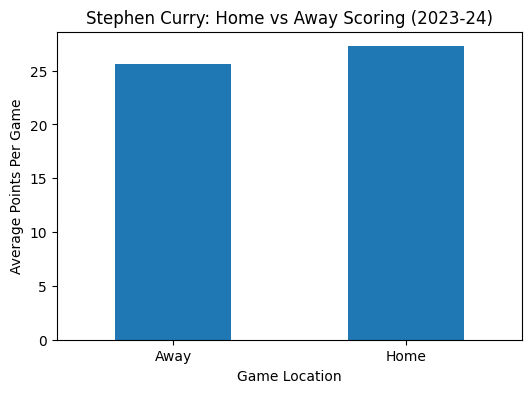

In [ ]:

# Plot comparison

plt.figure(figsize=(6,4))

avg_pts.plot(
    kind="bar",
)

plt.title("Stephen Curry: Home vs Away Scoring (2023-24)")
plt.ylabel("Average Points Per Game")
plt.xlabel("Game Location")
plt.xticks(rotation=0)

plt.show()

# Part II: Exercises


---



### TEAM MEMBERS

CLICK HERE TO ENTER TEAM MEMBER NAMES:



---



## Exercise 1: Efficiency vs. Volume

### A. For the 2023 - 2024 season, identify the 10 players with the highest field goal percentage (FG_PCT), field goal percentage on three-point shots (FG3_PCT), and free throw percentage (FT_PCT).  **Insert your code in the cell below**.


In [ ]:
### YOUR CODE FOR PART B GOES HERE

### B. Why might a player score a lot but not be the most efficient? What role does shot volume play? **Provide your answer in the cell below.**


YOUR ANSWER TO PART B HERE




### C. Create a scatter plot that shows total points scored vs field goal percentage. Filter total points scored to only show values above 300.


In [ ]:
### YOUR CODE FOR PART C GOES HERE

### D. What observations can we make based on the visualization?  Identify at least 3 observations.


YOUR ANSWER TO PART D HERE



---



## Exercise 2

### A. Next, we’ll explore how total points scored (PTS) relates to opportunity: games played (GP) and minutes played (MIN).

Pull the following columns for the top 10 scorers:
PLAYER, TEAM, PTS, GP, MIN

Create a scatter plot that shows total points scored vs minutes played. Label each data point with the player’s name.



In [ ]:
### YOUR CODE TO PART A HERE

### B. What are a few conclusions we can draw from this scatter plot?


CLICK HERE TO TYPE YOUR ANSWER FOR PART B

## Exercise 3

### A. Consider the home vs. away analysis above.  Rerun the analysis for a different player of your choice using a different metric (e.g. rebounds, assists, etc.).  Show the averages for this metric (home vs. away) and bar plot.

In [ ]:
### YOUR CODE FOR PART A HERE



### B. Compute the average for home and away games for 10 players of your choice.  Generate a scatter plot of these averages (home on the x-axis, and away on the y-axis).  Label each points with the player names.    

In [ ]:
### YOUR CODE FOR PART B HERE



## Reflections on the use of AI Tools

### A. What prompts did you give the AI tool? Include at least one example prompt. How did you revise or refine your prompts during the process?  If you didn't use AI tools, state so.


CLICK HERE TO TYPE YOUR ANSWER FOR PART A

### B. Did the AI produce any incorrect or misleading output? If so, describe what went wrong and how you fixed it. How did you verify that the AI-generated output was correct?


CLICK HERE TO TYPE YOUR ANSWER FOR PART B



###   